# PF-5039: Semana 01 - Práctica Asincrónica Desafío Avanzado
## Simulación de Aliasing Espacial, Filtro Antialiasing y Evaluación de PSNR en Retinografía

**Estudiantes:**
- Franco Castro Chaves, C01886
- Carolina Masis Calvo, A12127
- Emily Chacón Araya, C02047 

---
### Requerimientos del Desafío:
En esta práctica autónoma de 1 hora, estudiará en detalle cómo prevenir el fenómeno de Aliasing/Moiré en imágenes médicas de alta densidad cromática.

--- 
### Parte A: Simulación de Aliasing en una Grilla Sinusoidal Sintética
1. Genere una matriz de $512 \times 512$ píxeles representando la función matemática $f(x, y) = \sin(2\pi f_0 x) + \sin(2\pi f_0 y)$ con $f_0 = 15$.
2. Aplique un submuestreo por un factor de escala $S = 4$ mediante dos métodos:
   - **Método 1 (Submuestreo Directo sin Filtrado):** Tome cada $S$-ésimo píxel directo de la matriz (`pattern[::S, ::S]`).
   - **Método 2 (Submuestreo Filtrado Antialiasing):** Aplique un filtro pasa-bajo Gaussiano (`cv2.GaussianBlur`) con $\sigma = S/2 = 2.0$ y luego submuestree.
3. Grafique los 3 mapas de intensidad en paralelo e interpete la presencia de patrones Moiré.

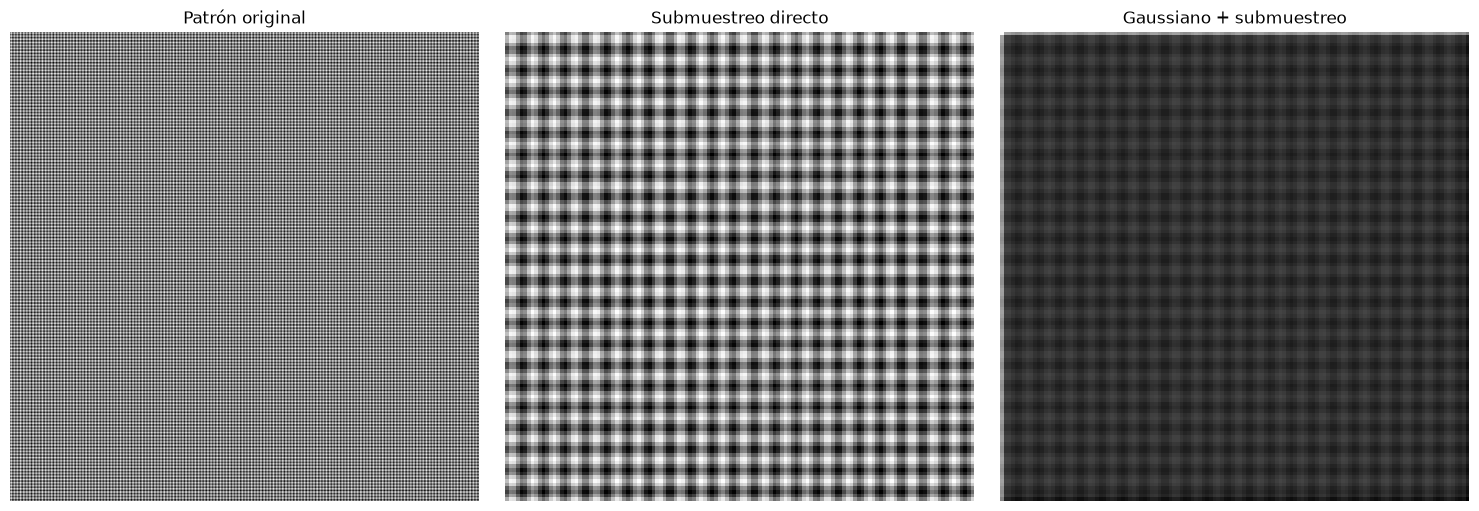

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PUNTO 1: Generación del patrón sinusoidal
# ============================================================

# Parámetros principales.
N = 512   # Número de muestras en cada dimensión del patrón.
f0 = 15   # Frecuencia espacial: 15 ciclos por unidad de coordenada.


# Generación de los vectores de coordenadas.
# x representa las posiciones horizontales de la imagen.
# y representa las posiciones verticales de la imagen.
#
# El enunciado no especifica el intervalo de valores para x e y.
# Por esta razón, se selecciona libremente el intervalo [0, 10]
# para ambas coordenadas.
#
# Como N = 512, cada vector contiene 512 valores
# uniformemente distribuidos entre 0 y 10.
#
# La separación entre muestras consecutivas es:
#
# Δx = Δy = 10 / (N - 1).

x = np.linspace(0, 10, N)
y = np.linspace(0, 10, N)


# Conversión de los vectores x e y en una cuadrícula bidimensional.
#
# X contiene la coordenada horizontal correspondiente a cada píxel.
# Y contiene la coordenada vertical correspondiente a cada píxel.
#
# Como x e y contienen 512 valores uniformemente distribuidos
# entre 0 y 10, X repite el vector x en cada fila y
# Y repite el vector y en cada columna.
#
# Ambas matrices tienen dimensiones 512 x 512.

X, Y = np.meshgrid(x, y)


# Generación del patrón sinusoidal.
#
# Se evalúa en cada posición (x, y) la función indicada:
#
# f(x,y) = sin(2*pi*f0*x) + sin(2*pi*f0*y)
#
# El primer término depende de la coordenada horizontal X.
# El segundo término depende de la coordenada vertical Y.
#
# El resultado f es una única matriz de 512 x 512 valores
# que representa el mapa de intensidad del patrón.

f = np.sin(2 * np.pi * f0 * X) + np.sin(2 * np.pi * f0 * Y)


# ============================================================
# PUNTO 2: Submuestreo de la imagen
# ============================================================

# Factor de submuestreo.
#
# S = 4 significa que se conservará una muestra de cada cuatro
# tanto en la dirección horizontal como en la vertical.

S = 4


# ------------------------------------------------------------
# MÉTODO 1: Submuestreo directo sin filtrado
# ------------------------------------------------------------

# [::S, ::S] selecciona:
#
# - una fila de cada 4;
# - una columna de cada 4.
#
# Por ejemplo, se conservan los índices:
# 0, 4, 8, 12, ...
#
# Como la imagen original mide 512 x 512:
#
# 512 / 4 = 128
#
# la nueva matriz tendrá dimensiones 128 x 128.

pattern_subsampled = f[::S, ::S]


# ------------------------------------------------------------
# MÉTODO 2: Filtro Gaussiano + submuestreo
# ------------------------------------------------------------

# El filtro Gaussiano se aplica antes de eliminar muestras.
#
# Su objetivo es atenuar las componentes de alta frecuencia espacial
# antes de reducir la frecuencia de muestreo, disminuyendo así
# la aparición de aliasing después del submuestreo.
#
# El enunciado establece:
#
# sigma = S / 2 = 2

sigma = S / 2


# Aplicación del filtro Gaussiano.
#
# f:
#     matriz original que será filtrada.
#
# (9, 9):
#     establece un kernel Gaussiano de 9 x 9 muestras.
#
# sigmaX=sigma:
#     establece la desviación estándar del filtro Gaussiano
#     en la dirección horizontal.
#
# Como sigmaY no se especifica, OpenCV utiliza el mismo
# valor de sigma en ambas direcciones.
#
# El resultado se almacena en f_filtrada.

f_filtrada = cv2.GaussianBlur(
    f,
    (9, 9),
    sigmaX=sigma
)


# Una vez filtrada la matriz, se realiza el mismo
# submuestreo utilizado en el Método 1.
#
# Se conserva una fila de cada 4 y una columna de cada 4.
#
# La matriz resultante también tendrá dimensiones 128 x 128.

f_subsampled_gaussian = f_filtrada[::S, ::S]


# ============================================================
# PUNTO 3: Visualización de los resultados
# ============================================================

# Se crea una figura que contiene tres espacios para imágenes.
#
# 1, 3:
#     indica que habrá 1 fila y 3 columnas.
#
# fig:
#     representa la figura completa.
#
# axes:
#     contiene los tres espacios individuales donde se
#     colocarán las imágenes.
#
# figsize=(15, 5):
#     establece únicamente el tamaño visual de la figura:
#     15 pulgadas de ancho y 5 pulgadas de alto.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# ------------------------------------------------------------
# Mapa 1: Patrón original
# ------------------------------------------------------------

# imshow() interpreta la matriz f como una imagen.
#
# cmap="gray" representa sus valores utilizando
# una escala de grises.

axes[0].imshow(f, cmap="gray")

# Título mostrado encima de la primera imagen.
axes[0].set_title("Patrón original")

# Se ocultan los ejes y sus valores numéricos para facilitar
# la observación del patrón.
axes[0].axis("off")


# ------------------------------------------------------------
# Mapa 2: Submuestreo directo
# ------------------------------------------------------------

# Se muestra la matriz obtenida al conservar una de cada
# cuatro filas y columnas sin aplicar ningún filtro previo.

axes[1].imshow(pattern_subsampled, cmap="gray")

# Título de la segunda imagen.
axes[1].set_title("Submuestreo directo")

# Se ocultan los ejes.
axes[1].axis("off")


# ------------------------------------------------------------
# Mapa 3: Filtro Gaussiano + submuestreo
# ------------------------------------------------------------

# Se muestra la matriz que primero fue suavizada mediante
# el filtro Gaussiano y posteriormente submuestreada.

axes[2].imshow(f_subsampled_gaussian, cmap="gray")

# Título de la tercera imagen.
axes[2].set_title("Gaussiano + submuestreo")

# Se ocultan los ejes.
axes[2].axis("off")


# Ajusta automáticamente los espacios entre los tres gráficos
# para evitar que los títulos o imágenes se sobrepongan.
plt.tight_layout()

# Muestra finalmente la figura completa.
plt.show()

### Discusión de los resultados

El patrón original contiene una frecuencia espacial de $f_0 = 15$ ciclos por unidad. Como las coordenadas se distribuyen uniformemente en el intervalo $[0,10]$ con $N=512$ muestras, la separación espacial es aproximadamente

$$
\Delta x = \Delta y = \frac{10}{511}.
$$

Por tanto, la frecuencia de muestreo espacial original es

$$
f_s \approx 51.1 \text{ muestras/unidad},
$$

y la frecuencia de Nyquist es

$$
f_N = \frac{f_s}{2} \approx 25.55 \text{ ciclos/unidad}.
$$

Como

$$
f_0 = 15 < 25.55,
$$

el patrón original puede representarse correctamente sin aliasing debido al muestreo inicial.

Al aplicar un submuestreo por un factor $S=4$, la frecuencia de muestreo se reduce a

$$
f_s' = \frac{51.1}{4} \approx 12.78 \text{ muestras/unidad},
$$

por lo que la nueva frecuencia de Nyquist es

$$
f_N' \approx 6.39 \text{ ciclos/unidad}.
$$

En este caso,

$$
f_0 = 15 > 6.39,
$$

por lo que la frecuencia original ya no puede representarse correctamente. Como consecuencia, aparece una frecuencia espacial aparente de menor valor. En este caso, la frecuencia alias es aproximadamente

$$
f_{\text{alias}} = |15 - 12.78| \approx 2.22 \text{ ciclos/unidad}.
$$

Esto explica el patrón más grueso observado en la imagen obtenida mediante **submuestreo directo**. Por lo tanto, dicho patrón corresponde efectivamente a **aliasing espacial**.

En el método **Gaussiano + submuestreo**, el filtro pasa-bajo se aplica antes de reducir la cantidad de muestras. Este filtro atenúa las componentes de alta frecuencia espacial, incluyendo la componente de $15$ ciclos por unidad, antes de realizar el submuestreo. Como resultado, la componente que produciría aliasing queda fuertemente reducida.

Sin embargo, el filtro Gaussiano no es un filtro pasa-bajo ideal, por lo que puede permanecer una pequeña componente residual. Por esta razón, todavía puede observarse cierta estructura periódica después del filtrado.

En conclusión, el patrón de menor frecuencia que aparece con el submuestreo directo es consecuencia del **aliasing espacial**, ya que la nueva frecuencia de muestreo no cumple el criterio de Nyquist para $f_0=15$. El filtrado Gaussiano previo reduce este fenómeno al atenuar las altas frecuencias antes de disminuir la resolución.

--- 
### Parte B: Evaluación Cuantitativa de PSNR en Submuestreo de Retinografía
1. Cargue la imagen médica `retinografia_microaneurismas.png` ($512 \times 512$).
2. Reduzca la resolución espacial a $128 \times 128$ ($S=4$) mediante submuestreo directo y submuestreo con filtro Gaussiano.
3. Vuelva a escalar ambas imágenes reducidas a la dimensión original de $512 \times 512$ (`cv2.INTER_NEAREST`) para poder compararlas matriz a matriz con la original.
4. Calcule la métrica PSNR (dB) para ambos métodos y concluya cuál preserva mejor la fidelidad estructural de la vascularización retiniana.

PSNR - Submuestreo directo: 41.49 dB
PSNR - Gaussiano + submuestreo: 41.52 dB


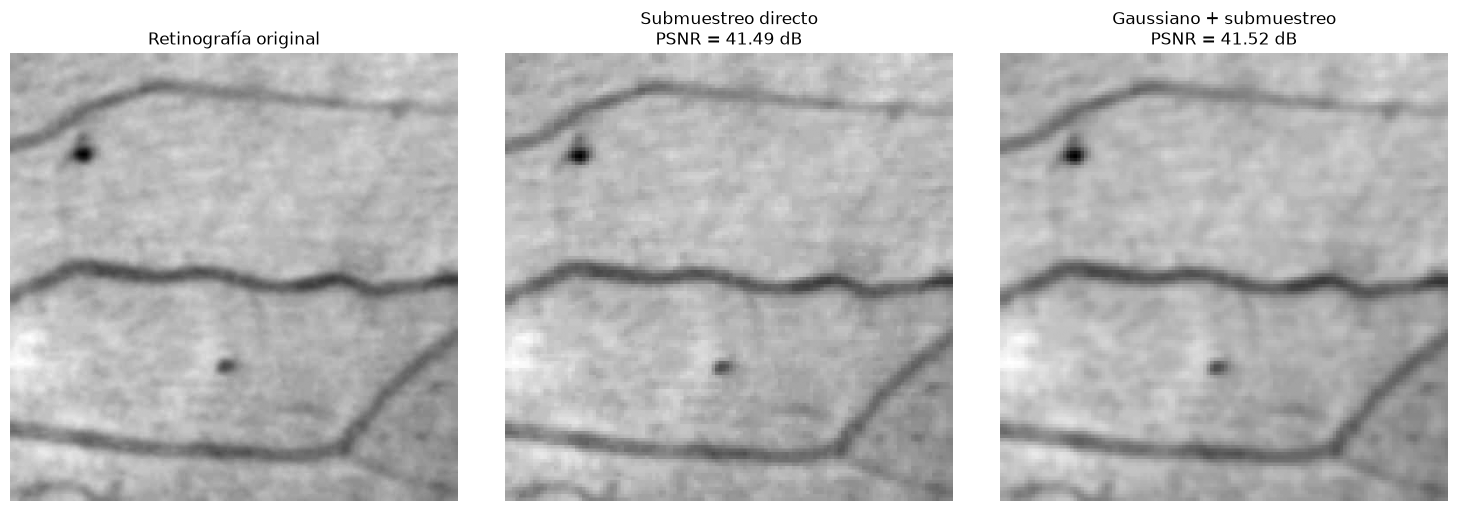

In [13]:
# ============================================================
# PARTE B - PUNTO 1: Carga de la retinografía
# ============================================================

# Se carga la imagen desde la carpeta indicada.
# cv2.imread() lee el archivo PNG y almacena sus píxeles
# en una matriz de NumPy.
retinografia = cv2.imread(
    "imagenes/retinografia_microaneurismas.png",
    cv2.IMREAD_GRAYSCALE
)

# ============================================================
# PARTE B - PUNTO 2: Reducción de resolución
# ============================================================

# Factor de submuestreo.
# S = 4 significa que se conservará una muestra de cada cuatro
# tanto en la dirección horizontal como en la vertical.
S = 4


# ------------------------------------------------------------
# MÉTODO 1: Submuestreo directo sin filtrado
# ------------------------------------------------------------

# Se toma una fila de cada 4 y una columna de cada 4.
# La imagen pasa de 512 x 512 a 128 x 128 píxeles.

retinografia_subsampled = retinografia[::S, ::S]


# ------------------------------------------------------------
# MÉTODO 2: Filtro Gaussiano + submuestreo
# ------------------------------------------------------------

# El enunciado establece que sigma = S / 2.
sigma = S / 2

# Se aplica primero un filtro Gaussiano para suavizar
# las variaciones espaciales rápidas antes del submuestreo.
#
# (0, 0) indica que OpenCV determina automáticamente
# el tamaño del kernel a partir de sigma.

retinografia_filtrada = cv2.GaussianBlur(
    retinografia,
    (0, 0),
    sigmaX=sigma
)

# Después del filtrado se toma una fila de cada 4
# y una columna de cada 4.
# La imagen resultante también tendrá 128 x 128 píxeles.

retinografia_subsampled_gaussian = retinografia_filtrada[::S, ::S]

# ============================================================
# PARTE B - PUNTO 3: Reescalado a la resolución original
# ============================================================

# Se define nuevamente el tamaño original de la imagen.
# OpenCV recibe el tamaño como (ancho, alto).
tamano_original = (512, 512)


# ------------------------------------------------------------
# Reescalado del submuestreo directo
# ------------------------------------------------------------

# cv2.resize() aumenta la imagen reducida de 128 x 128
# nuevamente a 512 x 512.
#
# INTER_NEAREST utiliza interpolación por vecino más cercano:
# cada nuevo píxel toma el valor del píxel más próximo.
#
# Este método no suaviza ni modifica los valores originales
# mediante promedios; simplemente replica muestras.

retinografia_directa_reescalada = cv2.resize(
    retinografia_subsampled,
    tamano_original,interpolation=cv2.INTER_NEAREST
)


# ------------------------------------------------------------
# Reescalado del submuestreo con filtro Gaussiano
# ------------------------------------------------------------

# Se realiza el mismo procedimiento para la imagen que fue
# filtrada con el Gaussiano antes del submuestreo.

retinografia_gaussiana_reescalada = cv2.resize(
    retinografia_subsampled_gaussian,
    tamano_original,interpolation=cv2.INTER_NEAREST
)

# ============================================================
# PARTE B - PUNTO 4: Cálculo de PSNR
# ============================================================

# Se calcula el PSNR entre la imagen original y la imagen
# obtenida mediante submuestreo directo.
psnr_directo = cv2.PSNR(
    retinografia,
    retinografia_directa_reescalada
)

# Se calcula el PSNR entre la imagen original y la imagen
# obtenida mediante filtro Gaussiano + submuestreo.
psnr_gaussiano = cv2.PSNR(
    retinografia,
    retinografia_gaussiana_reescalada
)

# Se muestran ambos resultados en decibelios (dB).
print(f"PSNR - Submuestreo directo: {psnr_directo:.2f} dB")
print(f"PSNR - Gaussiano + submuestreo: {psnr_gaussiano:.2f} dB")

# ============================================================
# PARTE B - VISUALIZACIÓN DE LOS RESULTADOS
# ============================================================

# Se crea una figura con 1 fila y 3 columnas.
# Cada columna mostrará una versión diferente de la retinografía.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# ------------------------------------------------------------
# Imagen 1: Retinografía original
# ------------------------------------------------------------

# Se muestra la imagen original en escala de grises.
axes[0].imshow(retinografia, cmap="gray")

# Se agrega un título.
axes[0].set_title("Retinografía original")

# Se ocultan los ejes para facilitar la comparación visual.
axes[0].axis("off")


# ------------------------------------------------------------
# Imagen 2: Submuestreo directo
# ------------------------------------------------------------

# Se muestra la imagen reconstruida a 512 x 512 después
# del submuestreo directo.
axes[1].imshow(retinografia_directa_reescalada, cmap="gray")

# Se incluye el valor de PSNR obtenido para este método.
axes[1].set_title(
    f"Submuestreo directo\nPSNR = {psnr_directo:.2f} dB"
)

# Se ocultan los ejes.
axes[1].axis("off")


# ------------------------------------------------------------
# Imagen 3: Filtro Gaussiano + submuestreo
# ------------------------------------------------------------

# Se muestra la imagen reconstruida a 512 x 512 después
# de aplicar el filtro Gaussiano y realizar el submuestreo.
axes[2].imshow(retinografia_gaussiana_reescalada, cmap="gray")

# Se incluye el valor de PSNR obtenido para este método.
axes[2].set_title(
    f"Gaussiano + submuestreo\nPSNR = {psnr_gaussiano:.2f} dB"
)

# Se ocultan los ejes.
axes[2].axis("off")


# Se ajusta automáticamente el espacio entre las imágenes
# para evitar que los títulos se sobrepongan.
plt.tight_layout()

# Se muestra la figura completa.
plt.show()


### Discusión de los resultados

La retinografía original presenta la mayor cantidad de detalle espacial, ya que conserva las $512 \times 512$ muestras originales. Al reducir la resolución a $128 \times 128$ píxeles, ambos métodos eliminan información espacial y posteriormente la imagen debe reescalarse para poder compararse con la original.

En el método de **submuestreo directo**, se conserva únicamente una muestra de cada cuatro en ambas direcciones sin aplicar un filtro previo. Debido a esto, las componentes de alta frecuencia espacial que superan la nueva frecuencia de Nyquist pueden producir aliasing.

En el método **Gaussiano + submuestreo**, primero se aplica un filtro pasa-bajo Gaussiano. Este filtro atenúa las componentes de alta frecuencia espacial antes de reducir la cantidad de muestras, lo que disminuye la posibilidad de aliasing. Sin embargo, el filtrado también produce un ligero suavizado de los detalles finos de la imagen.

Los valores obtenidos fueron

$$
PSNR_{\text{directo}} = 41.49 \text{ dB}
$$

y

$$
PSNR_{\text{Gaussiano}} = 41.52 \text{ dB}.
$$

Como un valor de PSNR más alto indica un menor error respecto de la imagen original, el método **Gaussiano + submuestreo** presenta una fidelidad ligeramente mayor.

La diferencia entre ambos resultados es

$$
41.52 - 41.49 = 0.03 \text{ dB}.
$$

Esta diferencia es muy pequeña, por lo que no puede afirmarse que exista una mejora significativa en la calidad global de la imagen. Según la métrica PSNR, ambos métodos presentan un desempeño muy similar, aunque el filtrado Gaussiano obtiene una ventaja marginal.

Además, el PSNR mide la diferencia global entre los valores de los píxeles, pero no evalúa directamente la conservación de estructuras anatómicas específicas, como vasos sanguíneos o microaneurismas.

En conclusión, el filtrado Gaussiano previo al submuestreo reduce las componentes de alta frecuencia que podrían generar aliasing y produce un PSNR ligeramente superior. Sin embargo, para esta retinografía, la diferencia de $0.03$ dB indica que ambos métodos conservan una fidelidad global prácticamente equivalente según esta métrica.